# Single Stream ResNet-18 Classification Model
Train a standard ResNet-18 model by pooling 6 versions of each image into a single dataset. This model relies entirely on **Classification** (Softmax) for verification, taking a single image as input.

In [ ]:
import random
import os
import numpy as np
import torch

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Global seed set to {seed} for reproducibility.")

seed_everything(42)

In [2]:
# ==========================================
# 1. IMPORTS & SETUP
# ==========================================
import os
import glob
import cv2
import numpy as np
import random
import time
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn.functional as F
from sklearn.metrics import roc_curve, confusion_matrix, accuracy_score
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from PIL import Image
import csv
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ==========================================
# 2. CONFIGURATION & TOGGLE
# ==========================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# TOGGLE DATASET HERE
USE_SDUMLA = False  # Set to True for SDUMLA, False for MMCBNU

# Setup logic based on toggle
KAGGLE_ENV = os.path.exists("/kaggle/input")
if KAGGLE_ENV:
    # Kaggle dataset path
    BASE_DIR_ROOT = "ADD PATH"

    WORK_DIR_ROOT = "/kaggle/working"
else:
    # Fallback to local machine path
    BASE_DIR_ROOT = "ADD PATH" 
    WORK_DIR_ROOT = "ADD PATH"

if USE_SDUMLA:
    DATASET_PREFIX = "SDUMLA-HMT_Preprocessed_v"
    IMG_SIZE = (224, 224)
    EXPERIMENT_NAME = "SDUMLA_Single_Stream_Classification"
else:
    DATASET_PREFIX = "MMCBNU_6000_Preprocessed_v"
    IMG_SIZE = (224, 224)
    EXPERIMENT_NAME = "MMCBNU_Single_Stream_Classification"

DATASET_VERSIONS = [os.path.join(BASE_DIR_ROOT, f"{DATASET_PREFIX}{i}") for i in range(1, 7)]

BATCH_SIZE = 64
EMBED_DIM = 512
NUM_EPOCHS = 10
LR = 3e-4
TRAIN_SPLIT = 0.8  # 80% images for training per class, 20% for testing (Classification requirement)

LOG_DIR = os.path.join(WORK_DIR_ROOT, "experiments", EXPERIMENT_NAME)
os.makedirs(LOG_DIR, exist_ok=True)

csv_log_path = os.path.join(LOG_DIR, "training_log.csv")
metrics_csv_path = os.path.join(LOG_DIR, "test_metrics.csv")

with open(csv_log_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "train_loss", "train_accuracy", "test_accuracy", "test_loss", "time_per_epoch"])

Using device: cuda


In [4]:
# ==========================================
# 3. DATASET DEFINITION & SPLIT
# ==========================================
class FingerVeinSingleStreamDataset(Dataset):
    def __init__(self, samples_and_labels, transform=None):
        self.transform = transform
        self.samples = samples_and_labels # List of (base_dir, rel_path, label)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        base_dir, rel_path, label = self.samples[idx]
        full_path = os.path.join(base_dir, rel_path)
        img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            img = np.zeros(IMG_SIZE, dtype=np.uint8)
            
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img_pil = Image.fromarray(img)
        
        if self.transform:
            img_t = self.transform(img_pil)
        else:
            img_t = transforms.ToTensor()(img_pil)
            
        return img_t, label

def prepare_data_splits(base_dirs, train_ratio=0.8):
    ref_dir = base_dirs[0]
    subjects = sorted([d for d in os.listdir(ref_dir) if os.path.isdir(os.path.join(ref_dir, d))])
    
    finger_map = {"L_Fore": 0, "L_Middle": 1, "L_Ring": 2, "R_Fore": 3, "R_Middle": 4, "R_Ring": 5}
    
    all_classes_data = {}
    
    for subject in subjects:
        subject_path = os.path.join(ref_dir, subject)
        try:
            subj_id = int(subject)
        except ValueError:
            continue
            
        for finger in os.listdir(subject_path):
            if finger not in finger_map:
                continue
            
            finger_path = os.path.join(subject_path, finger)
            images = sorted(glob.glob(os.path.join(finger_path, "*.png")) + glob.glob(os.path.join(finger_path, "*.bmp")))
            
            class_name = f"{subject}_{finger}"
            
            if class_name not in all_classes_data:
                all_classes_data[class_name] = []
                
            for img_path in images:
                rel_path = os.path.relpath(img_path, ref_dir)
                all_classes_data[class_name].append(rel_path)
                
    unique_classes = sorted(list(all_classes_data.keys()))
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(unique_classes)}
    idx_to_class = {idx: cls_name for idx, cls_name in enumerate(unique_classes)}
    NUM_CLASSES = len(unique_classes)
    
    train_items = []
    test_items = []
    
    for cls_name, rel_paths in all_classes_data.items():
        random.shuffle(rel_paths)
        split_idx = int(len(rel_paths) * train_ratio)
        idx = class_to_idx[cls_name]
        
        if split_idx == 0 and len(rel_paths) > 0:
            split_idx = 1 
            
        for p in rel_paths[:split_idx]:
            for base_dir in base_dirs:
                train_items.append((base_dir, p, idx))
        for p in rel_paths[split_idx:]:
            for base_dir in base_dirs:
                test_items.append((base_dir, p, idx))
            
    return train_items, test_items, NUM_CLASSES, idx_to_class

print("Indexing dataset and performing image splits...")
train_items, test_items, NUM_CLASSES, IDX_TO_CLASS = prepare_data_splits(DATASET_VERSIONS, TRAIN_SPLIT)

eval_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = FingerVeinSingleStreamDataset(train_items, transform=eval_transform)
test_dataset = FingerVeinSingleStreamDataset(test_items, transform=eval_transform)

print(f"Total Classes: {NUM_CLASSES}")
print(f"Training Images: {len(train_dataset)}")
print(f"Testing Images: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Indexing dataset and performing image splits...
Total Classes: 600
Training Images: 28800
Testing Images: 7200


In [5]:
# ==========================================
# 4. MODEL ARCHITECTURE
# ==========================================
class SingleStreamNet(nn.Module):
    def __init__(self, embed_dim=512, num_classes=636):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.embedding = nn.Linear(in_features, embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        f = self.backbone(x)
        f = self.embedding(f)
        logits = self.classifier(f)
        return f, logits

model = SingleStreamNet(embed_dim=EMBED_DIM, num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s]


In [6]:
# ==========================================
# 5. TRAINING LOOP
# ==========================================
def evaluate_classification(eval_model, t_loader):
    eval_model.eval()
    total_loss, correct = 0, 0
    
    with torch.no_grad():
        for images, labels in t_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                _, logits = eval_model(images)
                loss = criterion(logits, labels)
                
            total_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(1) == labels).sum().item()
            
    return total_loss / len(t_loader.dataset), correct / len(t_loader.dataset)

best_test_acc = 0.0

print(f"Starting Classification Training on {device}...")
for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()
    model.train()
    train_loss, train_correct = 0, 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            _, logits = model(images)
            loss = criterion(logits, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * labels.size(0)
        train_correct += (logits.argmax(1) == labels).sum().item()
        
        pbar.set_postfix({"loss": "{:.4f}".format(loss.item())})
        
    train_acc = train_correct / len(train_dataset)
    train_loss = train_loss / len(train_dataset)
    
    test_loss, test_acc = evaluate_classification(model, test_loader)
    epoch_time = time.time() - epoch_start
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time: {epoch_time:.1f}s")
    
    with open(csv_log_path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([epoch+1, train_loss, train_acc, test_acc, test_loss, epoch_time])
        
    if test_acc >= best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), os.path.join(LOG_DIR, "best_classification_model.pth"))

torch.save(model.state_dict(), os.path.join(LOG_DIR, "final_classification_model.pth"))
print("Training Complete! Model saved.")

Starting Classification Training on cuda...


Epoch 1/10: 100%|██████████| 450/450 [06:27<00:00,  1.16it/s, loss=1.5843]


Epoch 1/10 | Train Acc: 0.5512 | Test Acc: 0.9371 | Test Loss: 1.5440 | Time: 470.5s


Epoch 2/10: 100%|██████████| 450/450 [02:10<00:00,  3.44it/s, loss=1.1511]


Epoch 2/10 | Train Acc: 0.9868 | Test Acc: 0.9815 | Test Loss: 1.2481 | Time: 154.1s


...

Epoch 8/10 | Train Acc: 0.9999 | Test Acc: 0.9925 | Test Loss: 1.1369 | Time: 173.1s


Epoch 9/10: 100%|██████████| 450/450 [02:14<00:00,  3.35it/s, loss=1.0316]


Epoch 9/10 | Train Acc: 1.0000 | Test Acc: 0.9946 | Test Loss: 1.1330 | Time: 158.4s


Epoch 10/10: 100%|██████████| 450/450 [02:07<00:00,  3.53it/s, loss=1.0355]


Epoch 10/10 | Train Acc: 0.9999 | Test Acc: 0.9938 | Test Loss: 1.1290 | Time: 152.1s
Training Complete! Model saved.


Loading the best validated model for final evaluation...


Extracting Predictions: 100%|██████████| 113/113 [00:23<00:00,  4.79it/s]


Final Test Accuracy 0.9946
Precision (macro): 0.9951
Recall (macro): 0.9946
F1-score (macro): 0.9945


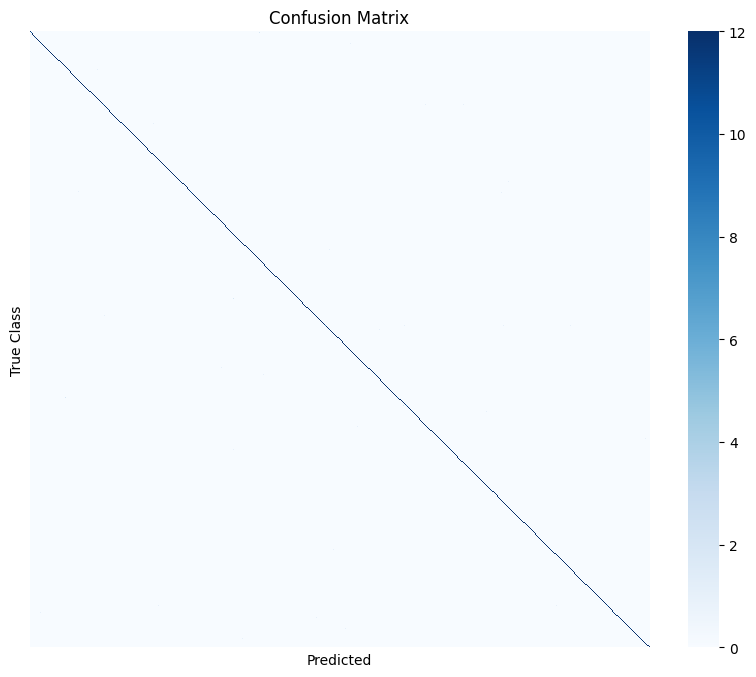

Equal Error Rate (ERR): 0.0006
Optimal Softmax Threshold for EER: 0.0122
Full ROC data saved to: /kaggle/working/experiments/MMCBNU_Single_Stream_Classification/roc_curve_full_data.csv


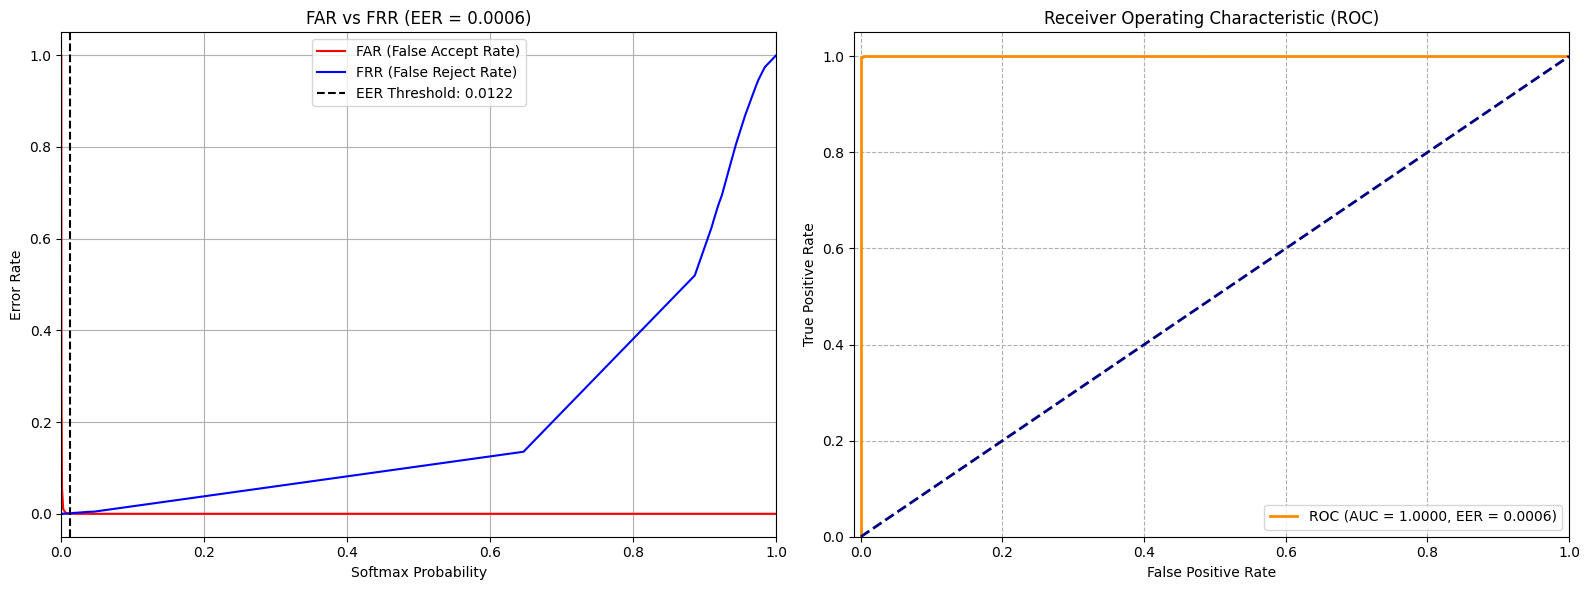

In [7]:
# ==========================================
# 6. EVALUATION METRICS (ROC, AUC, ERR, Confusion Matrix)
# ==========================================
print("Loading the best validated model for final evaluation...")
model.load_state_dict(torch.load(os.path.join(LOG_DIR, "best_classification_model.pth")))
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Extracting Predictions"):
        images = images.to(device)
        _, logits = model(images)
        probs = F.softmax(logits, dim=1)
        
        all_probs.append(probs.cpu())
        all_preds.append(logits.argmax(1).cpu())
        all_labels.append(labels)
        
all_probs = torch.cat(all_probs).numpy()
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# 1. Test Accuracy
final_test_acc = accuracy_score(all_labels, all_preds)

print("Final Test Accuracy {:.4f}".format(final_test_acc))
# ==========================================
# PRECISION / RECALL / F1 SCORE
# ==========================================
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

print("Precision (macro): {:.4f}".format(precision))
print("Recall (macro): {:.4f}".format(recall))
print("F1-score (macro): {:.4f}".format(f1))

# 2. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True Class")
plt.savefig(os.path.join(LOG_DIR, "confusion_matrix.png"), dpi=300)
plt.show()

# 3. ROC / ERR Calculation (Softmax Score based Authentication)
y_true_binary = []
y_scores = []

# For Verification setup: Genuine score against true class, Impostor against others
num_impostor_samples = 5

for i, true_label in enumerate(all_labels):
    y_true_binary.append(1)
    y_scores.append(all_probs[i, true_label])
    
    impostor_classes = np.random.choice([c for c in range(NUM_CLASSES) if c != true_label], num_impostor_samples, replace=False)
    for imp_class in impostor_classes:
        y_true_binary.append(0)
        y_scores.append(all_probs[i, imp_class])

fpr, tpr, thresholds = roc_curve(y_true_binary, y_scores)
fnr = 1 - tpr

eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
eer_threshold = float(interp1d(fpr, thresholds)(eer))

print("Equal Error Rate (ERR): {:.4f}".format(eer))
print("Optimal Softmax Threshold for EER: {:.4f}".format(eer_threshold))

# Save Metric Data for Easy Replotting
with open(metrics_csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["FPR", "FNR", "TPR", "Threshold"])
    for i in range(0, len(fpr), max(1, len(fpr)//500)):
        writer.writerow([fpr[i], fnr[i], tpr[i], thresholds[i]])

# 4. ROC Plots
from sklearn.metrics import auc
roc_auc = auc(fpr, tpr)
# ==========================================
# SAVE FULL ROC / FAR / FRR DATA
# ==========================================

roc_csv_path = os.path.join(LOG_DIR, "roc_curve_full_data.csv")

dataset_name = "SDUMLA" if USE_SDUMLA else "MMCBNU"
model_name = "ResNet18_SingleStream"

with open(roc_csv_path, "w", newline="") as f:
    writer = csv.writer(f)

    writer.writerow([
        "dataset",
        "model",
        "threshold",
        "FPR",
        "FNR",
        "TPR",
        "FAR",
        "FRR"
    ])

    for i in range(len(thresholds)):
        writer.writerow([
            dataset_name,
            model_name,
            thresholds[i],
            fpr[i],
            fnr[i],
            tpr[i],
            fpr[i],   # FAR = FPR
            fnr[i]    # FRR = FNR
        ])

print("Full ROC data saved to:", roc_csv_path)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(thresholds, fpr, label="FAR (False Accept Rate)", color="red")
axes[0].plot(thresholds, fnr, label="FRR (False Reject Rate)", color="blue")
axes[0].axvline(x=eer_threshold, color="black", linestyle="--", label="EER Threshold: {:.4f}".format(eer_threshold))
axes[0].set_title("FAR vs FRR (EER = {:.4f})".format(eer))
axes[0].set_xlabel("Softmax Probability")
axes[0].set_ylabel("Error Rate")
axes[0].set_xlim([0.0, 1.0])
axes[0].legend()
axes[0].grid(True)

axes[1].plot(fpr, tpr, color="darkorange", lw=2, label="ROC (AUC = {:.4f}, EER = {:.4f})".format(roc_auc, eer))
axes[1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
axes[1].set_xlim([-0.01, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Receiver Operating Characteristic (ROC)")
axes[1].legend(loc="lower right")
axes[1].grid(True, ls="--")

plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "roc_curves.png"))
plt.show()

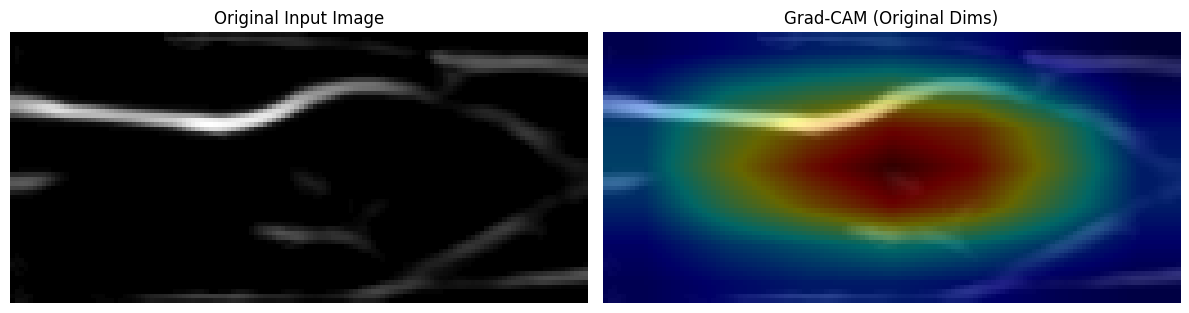

In [11]:
# ==========================================
# 7. EXPLAINABILITY (GRAD-CAM) IN ORIGINAL DIMENSIONS
# ==========================================
class SingleStreamGradCAM:
    def __init__(self, model):
        self.model = model
        self.feature_maps = None
        self.gradients = None
        # Hook into the last convolutional layer of ResNet18
        self.model.backbone.layer4.register_forward_hook(self.save_feature_maps)
        self.model.backbone.layer4.register_full_backward_hook(self.save_gradients)

    def save_feature_maps(self, module, input, output):
        self.feature_maps = output
        
    def save_gradients(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]
        
    def generate(self, input_tensor, orig_size, target_class=None):
        self.model.eval()
        _, logits = self.model(input_tensor)
        if target_class is None:
            target_class = logits.argmax(dim=1).item()
            
        self.model.zero_grad()
        score = logits[0, target_class]
        score.backward(retain_graph=True)
        
        weights = torch.mean(self.gradients, dim=[2, 3], keepdim=True)
        cam = torch.sum(weights * self.feature_maps, dim=1).squeeze(0)
        cam = F.relu(cam)
        
        cam = cam.cpu().detach().numpy()
        # Resize to original dimensions
        cam = cv2.resize(cam, orig_size)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

gcam = SingleStreamGradCAM(model)

idx = random.randint(0, len(test_dataset) - 1)
# Fetch the relative path of the test image so we can load the original to get its dimensions
base_dir, rel_path, _ = test_dataset.samples[idx]
original_img_path = os.path.join(base_dir, rel_path)

# Read original image
orig_img = cv2.imread(original_img_path, cv2.IMREAD_GRAYSCALE)
if orig_img is None:
    print('Failed to read original image')
else:
    orig_h, orig_w = orig_img.shape
    orig_size = (orig_w, orig_h)
    
    # Convert original to RGB for visualization base
    orig_img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_GRAY2RGB)
    
    sample_tensor, sample_label = test_dataset[idx]
    single_sample_tensor = sample_tensor.unsqueeze(0).to(device)
    
    # Generate Grad-CAM mask resized to original size
    cam_mask = gcam.generate(single_sample_tensor, orig_size)

    # Plot just the input image and the Grad-CAM side-by-side in original scales
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Show original Un-resized, Un-normalized base image
    axes[0].imshow(orig_img_rgb)
    axes[0].set_title('Original Input Image')
    axes[0].axis('off')
    
    # Process heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_mask), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    heatmap = heatmap[:, :, ::-1] # BGR to RGB
    
    # Normalize base image for overlay
    orig_img_norm = orig_img_rgb.astype(np.float32) / 255.0
    overlay = heatmap * 0.4 + orig_img_norm * 0.6
    
    axes[1].imshow(overlay)
    axes[1].set_title('Grad-CAM (Original Dims)')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(LOG_DIR, 'gradcam_original_dims.png'), dpi=300, bbox_inches='tight')
    plt.show()



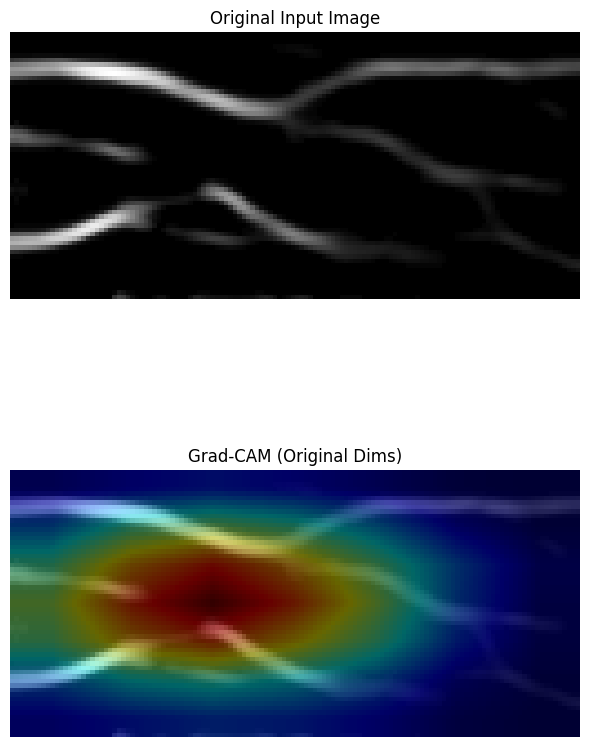

In [14]:
# ==========================================
# 7. EXPLAINABILITY (GRAD-CAM) IN ORIGINAL DIMENSIONS
# ==========================================
class SingleStreamGradCAM:
    def __init__(self, model):
        self.model = model
        self.feature_maps = None
        self.gradients = None
        # Hook into the last convolutional layer of ResNet18
        self.model.backbone.layer4.register_forward_hook(self.save_feature_maps)
        self.model.backbone.layer4.register_full_backward_hook(self.save_gradients)

    def save_feature_maps(self, module, input, output):
        self.feature_maps = output
        
    def save_gradients(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]
        
    def generate(self, input_tensor, orig_size, target_class=None):
        self.model.eval()
        _, logits = self.model(input_tensor)
        if target_class is None:
            target_class = logits.argmax(dim=1).item()
            
        self.model.zero_grad()
        score = logits[0, target_class]
        score.backward(retain_graph=True)
        
        weights = torch.mean(self.gradients, dim=[2, 3], keepdim=True)
        cam = torch.sum(weights * self.feature_maps, dim=1).squeeze(0)
        cam = F.relu(cam)
        
        cam = cam.cpu().detach().numpy()
        # Resize to original dimensions
        cam = cv2.resize(cam, orig_size)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam


gcam = SingleStreamGradCAM(model)

idx = random.randint(0, len(test_dataset) - 1)

# Fetch the relative path of the test image so we can load the original to get its dimensions
base_dir, rel_path, _ = test_dataset.samples[idx]
original_img_path = os.path.join(base_dir, rel_path)

# Read original image
orig_img = cv2.imread(original_img_path, cv2.IMREAD_GRAYSCALE)

if orig_img is None:
    print('Failed to read original image')
else:
    orig_h, orig_w = orig_img.shape
    orig_size = (orig_w, orig_h)
    
    # Convert original to RGB for visualization base
    orig_img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_GRAY2RGB)
    
    sample_tensor, sample_label = test_dataset[idx]
    single_sample_tensor = sample_tensor.unsqueeze(0).to(device)
    
    # Generate Grad-CAM mask resized to original size
    cam_mask = gcam.generate(single_sample_tensor, orig_size)

    # Plot input on top and Grad-CAM below
    fig, axes = plt.subplots(2, 1, figsize=(6, 10))
    
    # Show original Un-resized, Un-normalized base image
    axes[0].imshow(orig_img_rgb)
    axes[0].set_title('Original Input Image')
    axes[0].axis('off')
    
    # Process heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_mask), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    heatmap = heatmap[:, :, ::-1]  # BGR to RGB
    
    # Normalize base image for overlay
    orig_img_norm = orig_img_rgb.astype(np.float32) / 255.0
    overlay = heatmap * 0.4 + orig_img_norm * 0.6
    
    axes[1].imshow(overlay)
    axes[1].set_title('Grad-CAM (Original Dims)')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(LOG_DIR, 'gradcam_original_dims.png'), dpi=300, bbox_inches='tight')
    plt.show()